# **ВАРИАНТ 4**

---

### №1
#### **(2 балла)**

Предположим, что вы собираетесь в турпоход. У вас есть рюкзак, емкость которого составляет 6 фунтов, и список предметов, которые вы можете положить с собой в рюкзак. У каждого предмета есть вес и ценность.
Чем выше ценность, тем важнее для вас предмет.

**Нарисуйте и вручную заполните** таблицу, которая даст оптимальный набор предметов для похода и общую ценность получившегося рюкзака. Ориентируйтесь на алгоритм динамического программирования, описанный в лекции.

Список предметов возьмите согласно вашему варианту.

Вариант 4.
1. вода, 2 фунта, 6;
2. книга, 1 фунт, 3;
3. еда, 4 фунта, 9;
4. куртка, 1 фунт, 5;
5. камера, 3 фунта, 6 

|            | 0   | 1   | 2   | 3   | 4   | 5   | 6   |
| ---------- | --- | --- | --- | --- | --- | --- | --- |
| Вода-2-6   | 0   | 0   | 6   | 6   | 6   | 6   | 6   |
| Книга-1-3  | 0   | 3   | 6   | 9   | 9   | 9   | 9   |
| Еда-4-9    | 0   | 3   | 6   | 9   | 9   | 12  | 15  |
| Куртка-1-5 | 0   | 5   | 8   | 11  | 14  | 14  | 17  |
| Камера-3-6 | 0   | 5   | 8   | 11  | 14  | 14  | 17  |
- Куртка + еда + книга = 5 + 9 + 3 = 17

---

### №2
#### **(3 балла)**
Напишите программу, которая моделирует задачу о рюкзаке. Пользователь вводит объем рюкзака и список предметов с указанием их веса и ценности. Вам необходимо подобрать набор предметов максимальной ценности, которые поместятся в рюкзаке. Реализуйте три варианта решения этой задачи:

1. Полный перебор
2. Жадный алгоритм
3. Динамическое программирование

Укажите вычислительная сложность (в O-нотации) для каждого алгоритма. Постройте графики возрастания времени выполнения алгоритмов при увеличении входных данных.

Приведите примеры входных данных, когда жадный алгоритм дает оптимальное решение и когда дает неоптимальное решение.


ТЕСТОВЫЙ ПРИМЕР:
Вместимость рюкзака: 6

Предметы:
  Вода: вес=2, ценность=6, ценность/вес=3.00
  Книга: вес=1, ценность=3, ценность/вес=3.00
  Еда: вес=4, ценность=9, ценность/вес=2.25
  Куртка: вес=1, ценность=5, ценность/вес=5.00
  Камера: вес=3, ценность=6, ценность/вес=2.00

РЕЗУЛЬТАТЫ ДЛЯ ТЕСТОВОГО ПРИМЕРА:
Полный перебор: 17
Жадный алгоритм: 14
Динамическое программирование: 17


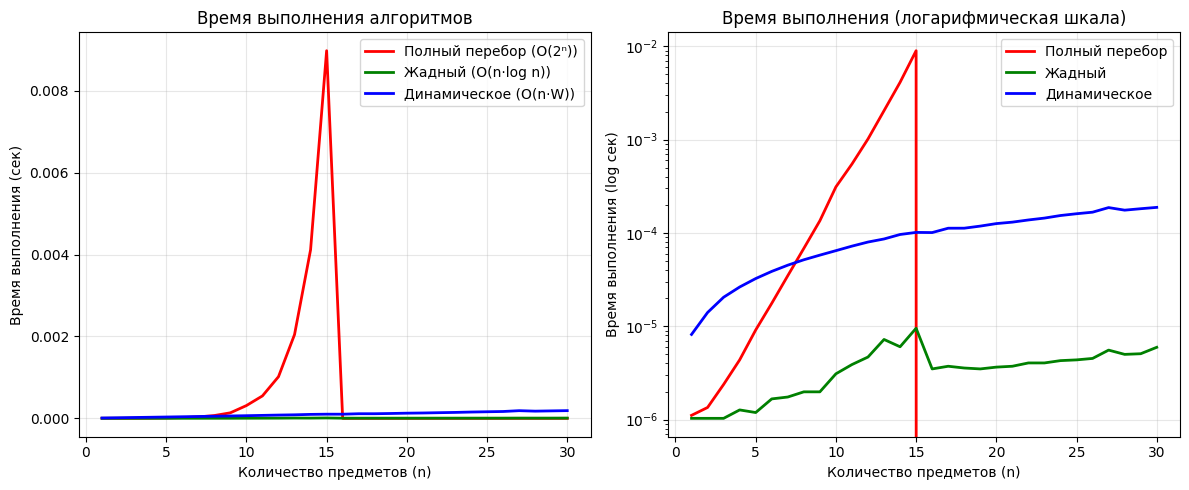

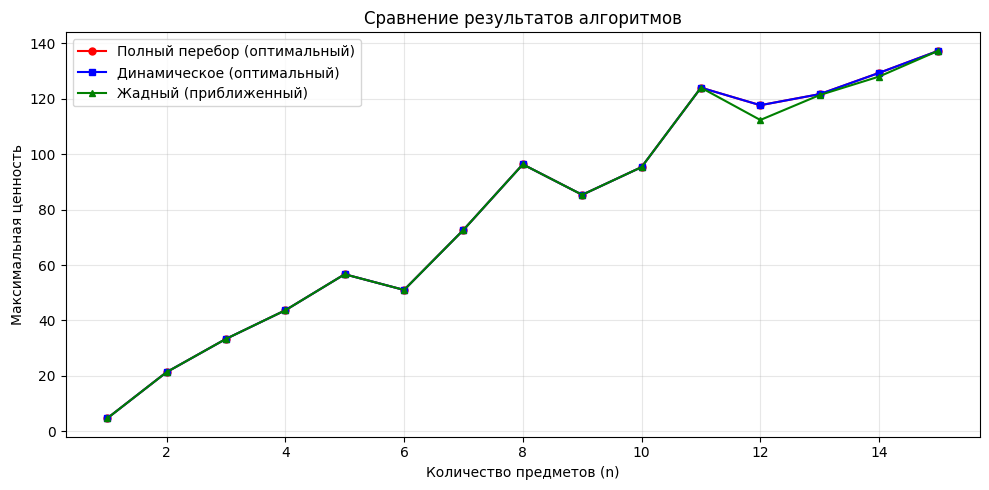

In [ ]:
from dataclasses import dataclass
from matplotlib import pyplot as plt
import random
import time
import itertools
from typing import List, Tuple

@dataclass
class Item:
    name: str
    weight: int
    value: int

# СЛОЖНОСТЬ: 2^N = 2^len(items)            
def first_brute_force(items: List[Item], capacity: int) -> Tuple[int, float]:
    start_time = time.time()
    
    def helper(index: int, current_capacity: int) -> int:
        if index == len(items) or current_capacity == 0:
            return 0

        item_weight = items[index].weight
        item_value = items[index].value

        # === ВАРИАНТ А: НЕ БРАТЬ ПРЕДМЕТ
        profit_skip = helper(index + 1, current_capacity)

        # === ВАРИАНТ Б: ВЗЯТЬ ПРЕДМЕТ
        profit_take = 0
        if item_weight <= current_capacity:   
            profit_take = item_value + helper(index + 1, current_capacity = current_capacity - item_weight) 

        # итоги
        return max(profit_skip, profit_take)

    result = helper(0, capacity)
    end_time = time.time()
    return result, end_time - start_time

# СЛОЖНОСТЬ: N * logN == len(items) * log(len(items))
def second_greedy(items: List[Item], capacity: int) -> Tuple[int, float]:
    start_time = time.time()
    
    sorted_items = sorted(items, key=lambda x: x.value / x.weight, reverse=True)

    current_capacity = capacity
    result = 0
    for item in sorted_items:
        if item.weight <= current_capacity:
            current_capacity -= item.weight
            result += item.value
            if current_capacity == 0:
                break
            
    end_time = time.time()
    return result, end_time - start_time

# СЛОЖНОСТЬ: N * capacity = len(items) * capacity
def third_dynamic(items: List[Item], capacity: int) -> Tuple[int, float]:
    start_time = time.time()
    
    table = [[0 for _ in range(capacity + 1)] for _ in range(len(items) + 1)]
    # table[items][weights]
    for i in range(1, len(items) + 1):
        current_item = items[i-1]
        weight = current_item.weight
        value = current_item.value
        
        result_skip = 0
        for w in range(capacity+1):
            result_take = 0
            # === ВАРИАНТ А: НЕ БРАТЬ ПРЕДМЕТ
            result_skip = table[i-1][w]
            
            # === ВАРИАНТ Б: ВЗЯТЬ ПРЕДМЕТ
            if weight <= w:
                result_take = value + table[i-1][w - weight]
            table[i][w] = max(result_skip, result_take)
    
    end_time = time.time()      
    return table[len(items)][capacity], end_time - start_time





# Далее всё что нужно для сравнений, графики, ...

def generate_random_items(n: int, max_weight: int = 10, max_value: int = 20) -> List[Item]:
    items = []
    for i in range(n):
        weight = random.randint(1, max_weight)
        value = random.randint(1, max_value)
        items.append(Item(f"Item_{i}", weight, value))
    return items

def benchmark_algorithms(max_items: int = 20, capacity: int = 30, num_tests: int = 5):
    # Тестирование алгоритмов на разных размерах входных данных
    sizes = []
    times_brute = []
    times_greedy = []
    times_dp = []
    values_brute = []
    values_greedy = []
    values_dp = []
    for n in range(1, max_items + 1, max(1, max_items // 20)):
        # Для точности делаем несколько тестов и берем среднее
        brute_times = []
        greedy_times = []
        dp_times = []
        brute_vals = []
        greedy_vals = []
        dp_vals = []
        
        for _ in range(num_tests):
            items = generate_random_items(n)
            
            # Полный перебор (только для небольших n)
            if n <= 15:  # Ограничиваем, так как полный перебор очень медленный
                val, t = first_brute_force(items, capacity)
                brute_times.append(t)
                brute_vals.append(val)
            else:
                brute_times.append(0)
                brute_vals.append(0)
            
            # Жадный алгоритм
            val, t = second_greedy(items, capacity)
            greedy_times.append(t)
            greedy_vals.append(val)
            
            # Динамическое программирование
            val, t = third_dynamic(items, capacity)
            dp_times.append(t)
            dp_vals.append(val)
        
        sizes.append(n)
        times_brute.append(sum(brute_times) / num_tests if brute_times[0] > 0 else 0)
        times_greedy.append(sum(greedy_times) / num_tests)
        times_dp.append(sum(dp_times) / num_tests)
        values_brute.append(sum(brute_vals) / num_tests if brute_vals[0] > 0 else 0)
        values_greedy.append(sum(greedy_vals) / num_tests)
        values_dp.append(sum(dp_vals) / num_tests)
    
    return sizes, times_brute, times_greedy, times_dp, values_brute, values_greedy, values_dp


def plot_results(sizes, times_brute, times_greedy, times_dp, 
                values_brute, values_greedy, values_dp):
    
    # График 1: Время выполнения
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(sizes, times_brute, 'r-', label='Полный перебор (O(2ⁿ))', linewidth=2)
    plt.plot(sizes, times_greedy, 'g-', label='Жадный (O(n·log n))', linewidth=2)
    plt.plot(sizes, times_dp, 'b-', label='Динамическое (O(n·W))', linewidth=2)
    plt.xlabel('Количество предметов (n)')
    plt.ylabel('Время выполнения (сек)')
    plt.title('Время выполнения алгоритмов')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Логарифмическая шкала для времени
    plt.subplot(1, 2, 2)
    plt.semilogy(sizes, times_brute, 'r-', label='Полный перебор', linewidth=2)
    plt.semilogy(sizes, times_greedy, 'g-', label='Жадный', linewidth=2)
    plt.semilogy(sizes, times_dp, 'b-', label='Динамическое', linewidth=2)
    plt.xlabel('Количество предметов (n)')
    plt.ylabel('Время выполнения (log сек)')
    plt.title('Время выполнения (логарифмическая шкала)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # График 2: Сравнение значений (ценности)
    plt.figure(figsize=(10, 5))
    
    # Отображаем только там, где есть данные
    valid_indices = [i for i, v in enumerate(values_brute) if v > 0]
    if valid_indices:
        valid_sizes = [sizes[i] for i in valid_indices]
        valid_brute = [values_brute[i] for i in valid_indices]
        valid_greedy = [values_greedy[i] for i in valid_indices]
        valid_dp = [values_dp[i] for i in valid_indices]
        
        plt.plot(valid_sizes, valid_brute, 'ro-', label='Полный перебор (оптимальный)', markersize=5)
        plt.plot(valid_sizes, valid_dp, 'bs-', label='Динамическое (оптимальный)', markersize=5)
        plt.plot(valid_sizes, valid_greedy, 'g^-', label='Жадный (приближенный)', markersize=5)
    else:
        plt.plot(sizes, values_dp, 'bs-', label='Динамическое (оптимальный)', markersize=5)
        plt.plot(sizes, values_greedy, 'g^-', label='Жадный (приближенный)', markersize=5)
    
    plt.xlabel('Количество предметов (n)')
    plt.ylabel('Максимальная ценность')
    plt.title('Сравнение результатов алгоритмов')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    

    
def main():
    # Тестовый пример из задания
    test_items = [
        Item('Вода', 2, 6),
        Item('Книга', 1, 3),
        Item('Еда', 4, 9),
        Item('Куртка', 1, 5),
        Item('Камера', 3, 6)
    ]
    test_capacity = 6
    
    print("\nТЕСТОВЫЙ ПРИМЕР:")
    print(f"Вместимость рюкзака: {test_capacity}")
    print("\nПредметы:")
    for item in test_items:
        print(f"  {item.name}: вес={item.weight}, ценность={item.value}, ценность/вес={item.value/item.weight:.2f}")
    
    print("\nРЕЗУЛЬТАТЫ ДЛЯ ТЕСТОВОГО ПРИМЕРА:")
    print(f"Полный перебор: {first_brute_force(test_items, test_capacity)[0]}")
    print(f"Жадный алгоритм: {second_greedy(test_items, test_capacity)[0]}")
    print(f"Динамическое программирование: {third_dynamic(test_items, test_capacity)[0]}")
    
    # Запуск бенчмарка
    sizes, times_brute, times_greedy, times_dp, values_brute, values_greedy, values_dp = benchmark_algorithms(
        max_items=30,  # Максимальное количество предметов
        capacity=50,   # Вместимость рюкзака
        num_tests=3    # Количество тестов для усреднения
    )
    
    # Построение графиков
    plot_results(sizes, times_brute, times_greedy, times_dp, 
                values_brute, values_greedy, values_dp)

main()

---

### №3
#### **(2 балла)**
Нарисуйте и вручную заполните таблицу для вычисления самой длинной общей подстроки между строками blue и clue. Ориентируйтесь на алгоритм динамического программирования, описанный в лекции

|   |   | c | l | u | e |
| - | - | - | - | - | - |
| b | 0 | 0 | 0 | 0 | 0 |
| l | 0 | 0 | **1** | 0 | 0 |
| u | 0 | 0 | 0 | **2** | 0 |
| e | 0 | 0 | 0 | 0 | **3** |

---

### №4
#### **(3 балла)**
Напишите программу, реализующую алгоритм нахождения самой длинной общей подстроки из лекции. Пользователь вводит слово с ошибкой и далее список похожих слов. Ваша программа должна вывести самое похожее слово согласно данному алгоритму.

In [9]:
def find_longest_common_substring(word_a, word_b):
    table = [[0] * (len(word_b) + 1) for _ in range(len(word_a) + 1)]
    max_len = 0
    for i in range(1, len(word_a) + 1):
        for j in range(1, len(word_b) + 1):
            if word_a[i-1] == word_b[j-1]:
                table[i][j] = table[i-1][j-1] + 1
            else:
                table[i][j] = 0
            if table[i][j] > max_len:
                max_len = table[i][j]
    return max_len

compare_word = input("Введите слово (с ошибкой): ")
dictionary = input("Введите список похожих слов ЧЕРЕЗ ПРОБЕЛ: ").split()

best_word = ""
max_overlap = 0

for word in dictionary:
    overlap = find_longest_common_substring(compare_word, word)
    if overlap > max_overlap:
        max_overlap = overlap
        best_word = word
        
print(f"Самое похожее слово: {best_word}")

Самое похожее слово: fosh


---

### №5
#### **(3 балла)**
Напишите программу, реализующую алгоритм нахождения самой длинной общей подпоследовательности из лекции. Пользователь вводит слово с ошибкой и далее список похожих слов. Ваша программа должна вывести самое похожее слово согласно данному алгоритму.

In [12]:
def find_longest_common_subsequence(word_a, word_b):
    table = [[0] * (len(word_b) + 1) for _ in range(len(word_a) + 1)]
    max_len = 0
    for i in range(1, len(word_a) + 1):
        for j in range(1, len(word_b) + 1):
            if word_a[i-1] == word_b[j-1]:
                table[i][j] = table[i-1][j-1] + 1
            else:
                table[i][j] = max(table[i-1][j], table[i][j-1])
            if table[i][j] > max_len:
                max_len = table[i][j]
    return max_len

compare_word = input("Введите слово (с ошибкой): ")
dictionary = input("Введите список похожих слов ЧЕРЕЗ ПРОБЕЛ: ").split()

best_word = ""
max_overlap = 0

for word in dictionary:
    overlap = find_longest_common_subsequence(compare_word, word)
    if overlap > max_overlap:
        max_overlap = overlap
        best_word = word
        
print(f"Самое похожее слово: {best_word}")

Самое похожее слово: hello


---

### №6
#### **(4 балла)**
Имеется n предметов различных размеров (от 0.1 до 1.0). Есть неограниченное количество одинаковых ящиков вместимостью 1.0. Необходимо разложить все n предметов в минимальное количество ящиков.

Напишите программу, реализующую 4 жадных стратегии раскладки предметов по ящикам:

1. Первый подходящий ящик. Ящики просматриваются поочередно пока не найдется ящик, в котором достаточно свободного места для упаковки очередного предмета. Если такого ящика нет, то предмет кладется в новый ящик. 

Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5) пройдет следующим образом: первый ящик — [0.5, 0.3, 0.1], второй — [0.7, 0.2], третий — [0.9], четвертый — [0.6, 0.4], пятый — [0.8], шестой — [0.5]. Т.е. ответом будет 6 ящиков.

2. Наиболее подходящий ящик. Выбирается ящик, в котором останется как можно меньше места после помещения туда очередного предмета. Укладка в новый ящик применяется только в том случае, если очередной предмет не помещается ни в какой из имеющихся ящиков.

Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5) пройдет следующим образом: первый ящик — [0.5, 0.5], второй — [0.7, 0.3], третий — [0.9, 0.1], четвертый — [0.6, 0.4], пятый — [0.8, 0.2]. Т.е. ответом будет 5 ящиков.

3. Следующий подходящий ящик. Мы продолжаем укладку каждого ящика до тех пор, пока очередной предмет в него помещается. Если предмет не влезает в ящик, то мы берем новый ящик, а к ранее уложенным ящикам уже не возвращаемся.

Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5) пройдет следующим образом: первый ящик — [0.5], второй — [0.7, 0.3], третий — [0.9], четвертый — [0.6], пятый — [0.8, 0.1], шестой — [0.4, 0.2], седьмой — [0.5]. 

Т.е. ответом будет 7 ящиков.

4. Наименее подходящий ящик. Выбирается ящик, в котором останется как можно больше места после помещения туда очередного предмета. Укладка в новый ящик применяется только в том случае, если очередной предмет не помещается ни в какой из имеющихся ящиков.

Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5) пройдет следующим образом: первый ящик — [0.5, 0.3], второй — [0.7], третий — [0.9], четвертый — [0.6, 0.1], пятый — [0.8], шестой — [0.4, 0.2], седьмой — [0.5]. 

Т.е. ответом будет 7 ящиков.

Сгенерируйте случайные наборы предметов (размером от 0.1 до 0.9) в количестве 50, 100, 200 и 500. Осуществите на каждом из наборов проверку всех четырех стратегий и посмотрите, какая из них приводит к меньшему числу ящиков.

В отчете приведите ваши результаты в виде таблицы

In [14]:
import random

# 1
def first_fit(items):
    bins = [] 
    for item in items:
        placed = False
        # Пробегаем по существующим ящикам
        for b in bins:
            load = sum(b) # текущая загрузка ящика
            if sum(b) + item <= 1.0 + 1e-9: # 1e-9 для борьбы с погрешностью float
                b.append(item)
                placed = True
                break
        
        # Если никуда не положили - создаем новый
        if not placed:
            bins.append([item])
            
    return len(bins)

# 2
def best_fit(items):
    bins = []   
    for item in items:
        max_fill_level = -1
        best_bin_index = -1
    
        for i in range(len(bins)):
            current_fill = sum(bins[i])
            if current_fill + item <= 1.0 + 1e-9:
                new_fill = current_fill + item
                if new_fill > max_fill_level:
                    max_fill_level = new_fill
                    best_bin_index = i
        if best_bin_index == -1:
            bins.append([item])
        else:
            bins[best_bin_index].append(item)
            
    return len(bins)

# 3
def next_fit(items):
    if not items:
        return 0
        
    # Сразу создаем первый ящик и кладем первый предмет
    bins = [[items[0]]]
    
    # Идем со второго предмета
    for item in items[1:]:
        last_bin = bins[-1]
        # Если влезает в последний
        if sum(last_bin) + item <= 1.0 + 1e-9:
            last_bin.append(item)
        else:
            # Иначе создаем новый
            bins.append([item])
            
    return len(bins)

# 4
def worst_fit(items):
    bins = []
    for item in items:
        min_fill_level = 2.0 
        best_bin_index = -1
        
        for i in range(len(bins)):
            current_fill = sum(bins[i])
            if current_fill + item <= 1.0 + 1e-9:
                new_fill = current_fill + item
                if new_fill < min_fill_level:
                    min_fill_level = new_fill
                    best_bin_index = i
        
        if best_bin_index == -1:
            bins.append([item])
        else:
            bins[best_bin_index].append(item)
    return len(bins)



# Размеры наборов для тестов
test_sizes = [50, 100, 200, 500]

print(f"{'Размер':<15} {'Первый':<12} {'Лучший':<12} {'Следующий':<12} {'Худший':<12}")
print("-" * 60)

for size in test_sizes:
    current_items = [round(random.uniform(0.1, 0.9), 2) for _ in range(size)]
    
    res1 = first_fit(current_items)
    res2 = best_fit(current_items)
    res3 = next_fit(current_items)
    res4 = worst_fit(current_items)
    
    print(f"{size:<15} {res1:<12} {res2:<12} {res3:<12} {res4:<12}")



Размер          Первый       Лучший       Следующий    Худший      
------------------------------------------------------------
50              34           34           39           35          
100             50           49           62           57          
200             114          112          138          122         
500             264          258          339          297         


---

### №7
#### **(4 балла)**
Есть купюры и монеты номиналами: 1, 3, 4, 10, 50, 100. В банкомате неограниченное количество купюр и монет каждого номинала. Мы хотим снять со счета n рублей. Нужно вывести на экран минимальный набор купюр и монет, который может выдать банкомат, чтобы сумма получилась ровно n.
1. Напишите жадный алгоритм решения задачи. Подсказка: выбирайте купюры и монеты по убыванию номинала.
2. Используйте динамическое программирование, чтобы рассчитать минимальное количество требуемых купюр и монет.
3. Приведите пример входных данных, когда жадный алгоритм выдает не оптимальное
решение.

In [16]:
def greedy_change(n, denominations):
    # Сортируем по убыванию, чтобы брать самые большие
    sorted_denoms = sorted(denominations, reverse=True)
    result = []
    current_sum = n
    
    for coin in sorted_denoms:
        while current_sum >= coin:
            current_sum -= coin
            result.append(coin)
            
    return result

def dp_change(n, denominations):
    dp = [float('inf')] * (n + 1)
    dp[0] = 0
    
    # coin_used[i] хранит последнюю монету, которую добавили к сумме i
    coin_used = [0] * (n + 1)
    
    for i in range(1, n + 1):
        for coin in denominations:
            if i >= coin:
                # Если, взяв эту монету, мы улучшаем результат для суммы i
                if dp[i - coin] + 1 < dp[i]:
                    dp[i] = dp[i - coin] + 1
                    coin_used[i] = coin
    
    # Восстанавливаем ответ (обратный ход)
    result = []
    curr = n
    
    # Если dp[n] так и осталось inf, значит сумму собрать нельзя
    if dp[n] == float('inf'):
        return None 

    while curr > 0:
        coin = coin_used[curr]
        result.append(coin)
        curr -= coin
        
    return result


denominations = [1, 3, 4, 10, 50, 100]
target_sum = 6  # Пример, где Жадный ошибается
print(f"Цель: {target_sum}")

greedy_res = greedy_change(target_sum, denominations)
print(f"Жадный алгоритм: {greedy_res} (Кол-во: {len(greedy_res)})")
# Ожидание: [4, 1, 1] (3 монеты)

dp_res = dp_change(target_sum, denominations)
print(f"DP алгоритм:     {dp_res} (Кол-во: {len(dp_res)})")
# Ожидание: [3, 3] (2 монеты)

if len(greedy_res) > len(dp_res):
    print("ВЫВОД: Жадный алгоритм НЕ оптимален в этом случае.")
else:
    print("ВЫВОД: Оба алгоритма дали одинаковый результат.")


Цель: 6
Жадный алгоритм: [4, 1, 1] (Кол-во: 3)
DP алгоритм:     [3, 3] (Кол-во: 2)
ВЫВОД: Жадный алгоритм НЕ оптимален в этом случае.


### № 8
#### **(4 балла)**
Напишите программу, моделирующую работу клиентов с банкоматом. В банкомате есть купюры и монеты номиналами: 1, 3, 4, 10, 50, 100, но, в отличие от предыдущей задачи, их количество конечно.

В начале работы программы вы задаете:

- количество клиентов
- для каждого клиента количество рублей, которые он хочет снять (считаем, что эта сумма всегда корректна и имеется на счету клиента)
- изначальное количество купюр и монет в банкомате

Далее вы по очереди обрабатываете запросы клиентов. Для каждого клиента выведите на экран минимальный набор купюр и монет для его суммы или сообщение о невозможности предоставить данную суммы из-за нехватки купюр и монет. Если минимальный набор найден успешно, то вычтите его из запасов банкомата и выведите на экран получившейся остаток.

Проведите несколько запусков программы с разными начальными данными и различными исходами работы с банкоматом.